< [How to Read and Represent Data](../ica02/How_to_Read_and_Represent_Data.ipynb) | Contents (TODO) | [Data Preprocessing and Visualization](../ica04/Data_Preprocessing_and_Visualization.ipynb) >

<a href="https://colab.research.google.com/github/stephenbaek/bigdata/blob/master/in-class-assignments/ica03/Data_Mining.ipynb"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>

# Data Mining

Data mining is the practice of examining data sources in order to generate new information. People say [data is the new oil](https://www.economist.com/leaders/2017/05/06/the-worlds-most-valuable-resource-is-no-longer-oil-but-data) (* and also [otherwise](https://www.forbes.com/sites/bernardmarr/2018/03/05/heres-why-data-is-not-the-new-oil/#1b2106913aa9)...). So we can arrive at this ~~cheesy~~ analogy that data mining is like mining the oil.

Nonetheless, what we are going to do today in this notebook are threefold. First, we are going to see how to access a large collection of public data sets published on a website called, Kaggle. Second, we will get a feel of web crawling/scraping by extracting some living information on the web. Last but not the least, we are going to see how data APIs generally work.

## 1. Kaggle Datasets

In short, Kaggle is a sort of online community for data scientists, now owned by Google (as of 2017). The community allows its users (called Kagglers) to publish data sets, build models in a web-based data-science environment, enter data science challenge competitions, exchange ideas/codes, etc. Around the time Google acquired Kaggle, its user base passed 1,000,000 registered users, spanning 190+ countries, forming the largest and most diverse data science community in the world.

Especially for students of data science, it is an extremely useful source of materials, not just because of the gigantic amount of real-world data sets and data science problems, but also because of the source codes, ideas, etc. shared by other Kagglers. In this section, I'll show one of (many) ways to use Kaggle for your own project.


### 1.1. Getting Started

#### Sign up
Well, first off, you have to sign up (again, I'm not getting paid by Google for encouraging you to sign up :)). The sign up process is rather simple, so I won't explain here. Once the sign up process is complete, just go ahead and navigate what they have on the website. Especially, try to click `Competitions` menu on top, and see the list of competitions. Also, make sure to check out `Datasets` menu, where you can find tens of thousands of real-world data set for free. Lastly, `Notebooks` can be a great place for your future projects, to get an idea of how to solve a specific problem, etc.

#### Create an API Token
Now, go to `My Account` by clicking the user profile at the top right corner.
![User settings menu](https://github.com/stephenbaek/bigdata/blob/master/in-class-assignments/ica03/figures/kaggle_my_account.png?raw=1)

Scroll down a bit and you will find an API section. Click '`Create New API Token`' button.
![Create New Kaggle API Token](https://github.com/stephenbaek/bigdata/blob/master/in-class-assignments/ica03/figures/create_new_kaggle_api_token.png?raw=1)

This will download a file named `kaggle.json`. Open it with a text editor. You will see something like this in the file.
```json
{"username":"bigdata","key":"0123456789abcdefghijklmn"}
```
Make sure to keep it opened somewhere as you will need it a few cells later.

### 1.2. Install Python Kaggle Library

Now, in order to use Kaggle on your local machine (or Google Colab), you will need to install python Kaggle library, which can be done simply by one line of code.

In [ ]:
# This is how you install a python library
!pip install kaggle

Now, the next thing is to provide the Kaggle API token to the library we just installed so that it knows you are a legitimate Kaggler. To this, copy and past the contents of the json file you downloaded above in the cell below.

In [ ]:
# type your Kaggle API token here
token = {"username":"bigdata","key":"0123456789abcdefghijklmn"}

Now the code below is for advanced users only. You don't have to understand them line by line. Just run the cell and safely ignore what's in it. Just keep in mind in the future that there was something about the API token and you needed to set it up. When you need to do it again in the future, just come back to this notebook and copy the code and reuse it.

In [ ]:
# This cell is only for advanced users. Run this cell and you can safely move on to the next cell
import os
from pathlib import Path
import json
import platform

# creates and places the token file at a desired location
home = str(Path.home())
kaggle_root = os.path.join(*[home, '.kaggle'])
os.mkdir(kaggle_root)
with open(os.path.join(*[kaggle_root, 'kaggle.json']), 'w') as file:
    json.dump(token, file)

# make the key file accessible only to the owner
if platform.system() == 'Windows':
    !attrib -R {os.path.join(*[kaggle_root, 'kaggle.json'])}
else:
    !chmod 600 {os.path.join(*[kaggle_root, 'kaggle.json'])}

### Alternative Method (Colab Only)

If you are using Colab, you can upload the json file using the file dialog below.

In [ ]:
from google.colab import files
uploaded = files.upload()

Then, run the cell below.

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

### 1.3. Downloading a Data Set from Kaggle

Downloading a data set from kaggle is as simple as just one line.
```bash
!kaggle datasets download -d <path-to-dataset> -p <download-location>
```

Path to data set is what comes after `http://www.kaggle.com/` in the data set URL. For example, somebody gathered avocado prices and published as a data set in kaggle, which can be found at https://www.kaggle.com/neuromusic/avocado-prices. So In this case, the path to data set is `neuromusic/avocado-prices`.

Download location means the name of the folder on your hard drive (or Google virtual machine's hard drive, if you're using Colab). Say, you want to create a folder called `data` under the present working directory (where this notebook `ipynb` file is located). You can simply type something like below to download the avocado data set under the said folder.

In [ ]:
!kaggle datasets download -d neuromusic/avocado-prices -p data

Many of the data sets in Kaggle come with some sort of a compressed file (e.g. zip file in this case). For Mac/Linux users, you can simply type in a code cell:
```bash
!unzip ./data/avocado-prices.zip -d ./data
```
to extract all the contents of the zip file into the data folder. If you are a Windows user, however, the story is a bit different. You will in fact have to unzip the file manually by opening up the 'File Explorer' and tracking down to the folder that you downloaded the dataset. If you have 7-zip or other Windows unzip tools installed already, or if you have Java Development Kit installed, there are ways to achieve this conveniently in a notebook, without having to do everything manually (see [this](https://stackoverflow.com/questions/1021557/how-to-unzip-a-file-using-the-command-line) for detail). However, certainly, this is beyond the scope of this class, so I won't dive too much into details.

In [ ]:
# Unzipping files.
if platform.system() == 'Windows':
    this_file_path = !echo %cd%
    data_path = os.path.join(*[this_file_path[0], 'data'])
    print('[IMPORTANT] No automatic unzipping supported on Windows.')
    print('You have to open `File Explorer` and manually unzip `' + data_path + '\\avocado-prices.zip`')
    print('Make sure `avocado.csv` file in the zip file is placed directly under `data` folder:')
    print('|- ica03')
    print('    |- data')
    print('        |- avocado.csv')
    print('    |- Data_Mining.ipynb')
else:
    !unzip ./data/avocado-prices.zip -d ./data

Okay, now you are ready to play with the avocado data. The avocado data set comes with a single comma seprated values (CSV) file.

### 1.4. Assignment

Find a data set on Kaggle with a search keyword "iowa". Read the downloaded data set as Spark DataFrame. Display summary statistics.

## 2. Web Scraping with BeautifulSoup

BeautifulSoup is a python library that comes with a lot of handy functions for web scraping and gathering information from the internet. There are so many things you can do with BeutifulSoup, but in this notebook, I'll show you a rather specific example of how BeutifulSoup can be applied for data mining.

To this, we will use the Eastern Iowa - Cedar Rapids Airport website as an example. There, they provide a real-time flight status update for travellers (https://flycid.com/flight-status/). Let's click and open this website and see how it look like.

![Cedar Rapids Airport Webpage](https://github.com/stephenbaek/bigdata/blob/master/in-class-assignments/ica03/figures/cid_web.png?raw=1)

### 2.1. Anatomy of a Web Page

Different people would have different approaches, but what I usually do is to take a look at the anatomy of the web page using my web browser's developer tool. If you use Chrome or Firefox, the developer tool can be opened by pressing `ctrl (cmd) + shift + I` or `F12`. If you use Safari, it is called Web Inspector, and can be opened with `cmd + shift + I`. For other web browsers, there should be a menu somewhere, or an instruction on the internet.

Now, in the developer tool, you should find some scripts which define the web page. In Chrome, it looks like this:

![Developer Tools in Chrome](https://github.com/stephenbaek/bigdata/blob/master/in-class-assignments/ica03/figures/dev_tools.png?raw=1)

The script here looks a lot like XML we learned in the [previous lecture](https://docs.google.com/presentation/d/17HzZmXP-xWtvgPrPOptM-AEKFnGaUJSzmEiJjz784_c/edit?usp=sharing). It is in fact called Hypertext Markup Language, or HTML, which is a standard markup language for web documents. You don't have to know all the tags of HTML. However, if you are curious about some basic HTML tags, here's a [nice summary of most commonly used HTML tags](https://www.geeksforgeeks.org/most-commonly-used-tags-in-html/).

Now, most web browsers highlights a specific part of web document when you hover a mouse cursor over a script in the developer tool, like in the screenshot below.

![Developer Tools can Highlight Areas](https://github.com/stephenbaek/bigdata/blob/master/in-class-assignments/ica03/figures/code_highlight.png?raw=1)

This is where your job as a data scientist gets less elegant but a little dirty and brute force (welcome to the real world!): The first thing to do to extract an information from a web document is to figure out exactly where the desired information is located. In this example, after a few minutes of digging in (basically hovering the mouse cursor on different locations of the HTML scripts), I found that the flight information was being displayed as an `iframe`, which is basically like a web page within a web page.

![Actual Flight Information in iframe](https://github.com/stephenbaek/bigdata/blob/master/in-class-assignments/ica03/figures/iframe.png?raw=1)

What this means is that the airport website is not actually doing anything by itself to retrieve the flight information, but instead, displays an external web page (https://webservice.prodigiq.com/wfids/CID/small?rows=18) within the airport web page as if it is a part of the web page. Long story short, this is where all the desired information we need and, hence, where we will do the web scraping.

### 2.2. Get and Parse HTML

Now that we know where the information exists, let's retrieve the HTML tags and parse them into a useful information for us. First off, let's retrieve the entire web page.

In [ ]:
import requests
page = requests.get("https://webservice.prodigiq.com/wfids/CID/small?rows=18")

Now, with BeutifulSoup, we parse the information and display it in the notebook.

In [ ]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(page.content, 'html.parser')

In [ ]:
print(soup.prettify())

There are a lot of things going on, but after another dirty work of digging into the tags, we can find the flight information table lives in the tag `table` with an attribute `class="views-table cols-5"`, which can be searched by BeutifulSoup:

In [ ]:
table = soup.find('table', {'class': 'views-table cols-5'})
print(table)

Furthermore, within the table, it seems like all the flight information is structured within `tbody` tag.

In [ ]:
tbody = table.find('tbody')
tbody

For further break down, each flight now is within `tr` task. So, we are going to find all `tr` tags in `tbody` and create a list. Just as a crash HTML course, `tr` is an abbreviation for 'table row' while `td` is for 'table data (column)'.

In [ ]:
trows = tbody.find_all('tr')
trows[0]

As we can see, each table row (`tr`) contains multiple table data (`td`). In this case, the first (counting from zero) `td` tag contains the flight number, the second contains the city of departure, the third the arrival time, the fourth baggage claim, and last the arrival status:

In [ ]:
print('{:10s} | {:15s} | {:15s} | {:15s} | {:10s}'.format(
    'Flight', 'Departure City', 'Arrival Time', 'Baggage Claim', 'Status'))
for i, trow in enumerate(trows):
    titems = trow.find_all('td')   # find all the data items in each row
    print('{:10s} | {:15s} | {:15s} | {:15s} | {:10s}'.format(
        titems[1].contents[0],          # contents of the first table item (column)
        titems[2].contents[0],          # contents of the second table item
        titems[3].contents[0],          # contents of the third table item
        titems[4].contents[0],          # contents of the fourth table item
        titems[5].contents[0],          # contents of the fifth table item
    ))

There, now you can retrieve the real-time flight arrival information at the Cedar Rapids Airport!

### 2.3. Assignment: College of Engineering Faculty-Staff Directory

Use BeautifulSoup to parse the college of engineering faculty-staff directory from https://www.engineering.uiowa.edu/faculty-staff-directory. Create a Spark DataFrame containing the following columns: `first-name`, `last-name`, `middle-initial`, `title`, `department`, `email`, `campus-address`, and `image-url`.

## 3. Get Live Stock Price using `yahoo_fin` API

As we have seen above, writing a scraping/crawling code from scratch involves a lot of dirty, brute-force works. For many cases, however, there are people who have already gone through all these and quite generously decided to build a set of handy functions that let you skip all those hassles. Or, sometimes, engineers and developers at companies, who actually built the web pages and knows exactly how the information is structured, decided to provide "nerd users" like me ways to access their data. Whatever the reason was, a data set API is basically a predefind set of functions that helps you access the data.

In this quick example, we are going to retrive real-time stock price data using Yahoo! Finance API (`yahoo_fin`). Let us first install `yahoo_fin` API.

In [ ]:
!pip install --upgrade yahoo_fin

Now, `yahoo_fin` library comes with lots of modules in it. Among them, in this example, we are going to use `stock_info` module. Importing it should look like this:

In [ ]:
from yahoo_fin import stock_info as si

For data set APIs, we are not going to get too much into details, but here are several things you can do to retrieve real-time stock info.

In [ ]:
# Get Netflix (NFLX) stock info from year 2015 to 2018
data = si.get_data('NFLX', start_date='01/01/2015', end_date='12/31/2018')
data

In [ ]:
data.index # gives time stamps

In [ ]:
data['volume'].values  # gives values of the column named 'volume'

In [ ]:
data[['open','close']].values # gives multiple columns

## 4. Conclusion

We saw a few examples in this notebook of how to gather data from (1) public data repository, (2) manual web scraping, and (3) data set API functions. There are actually a lot more things to cover just for this topic of data mining and what you just saw above are just a tip of the iceberg. But don't worry. As long as you understand the principles above, learning other tools/methods shouldn't be a big challenge, but just a little bit of investment of time to get to know all those commands and etc.

< [How to Read and Represent Data](../ica02/How_to_Read_and_Represent_Data.ipynb) | Contents (TODO) | [Data Preprocessing and Visualization](../ica04/Data_Preprocessing_and_Visualization.ipynb) >

<a href="https://colab.research.google.com/github/stephenbaek/bigdata/blob/master/in-class-assignments/ica03/Data_Mining.ipynb"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install mlxtend imbalanced-learn shap umap-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, roc_auc_score, roc_curve)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import umap
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# Clean dataset - remove unnamed columns
df = df.iloc[:, :33].copy()

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# Handle missing values
df['alcohol_consumption'].fillna('None', inplace=True)
df['symptoms_list'].fillna('None', inplace=True)

Saving vitamin_deficiency_disease_dataset_20260123 2.xlsx - vitamin_deficiency_disease_data.csv to vitamin_deficiency_disease_dataset_20260123 2.xlsx - vitamin_deficiency_disease_data (1).csv
Dataset Shape: (4000, 33)

Columns: ['age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'symptoms_count', 'symptoms_list', 'has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin', 'disease_diagnosis']


BASIC STATISTICS
               age          bmi  vitamin_a_percent_rda  vitamin_c_percent_rda  \
count  4000.000000  4000.000000            4000.000000            4000.000000   
mean     50.766250    26.105325              90.770850              89.199075   
std      19.306237     4.922746              37.083534              37.505809   
min      18.000000    15.000000              10.000000              10.000000   
25%      34.000000    22.800000              62.600000              60.975000   
50%      51.000000    26.200000              85.500000              83.500000   
75%      67.000000    29.400000             115.300000             113.000000   
max      84.000000    45.000000             219.000000             250.000000   

       vitamin_d_percent_rda  vitamin_e_percent_rda  vitamin_b12_percent_rda  \
count            4000.000000            4000.000000              4000.000000   
mean               72.216388              89.946125                62.743225   
std          

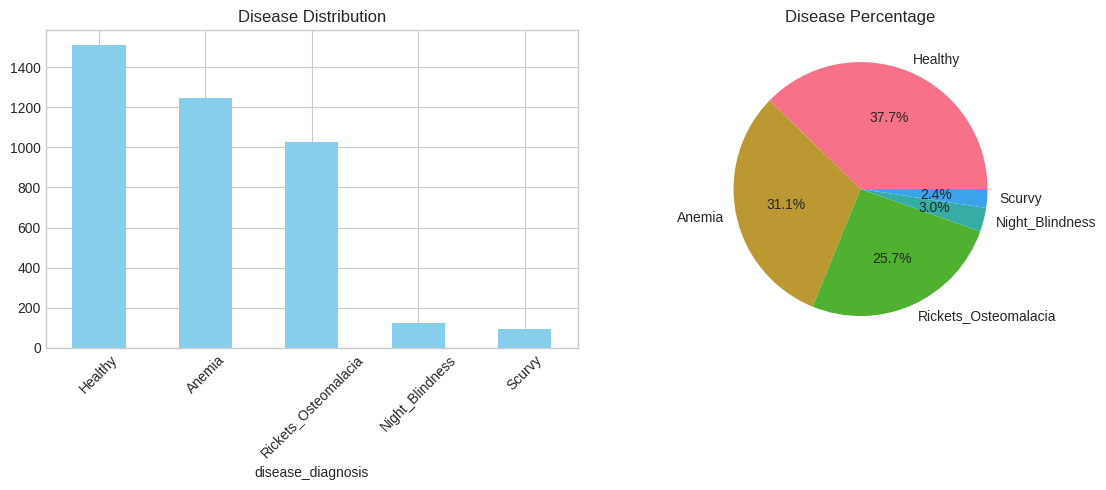

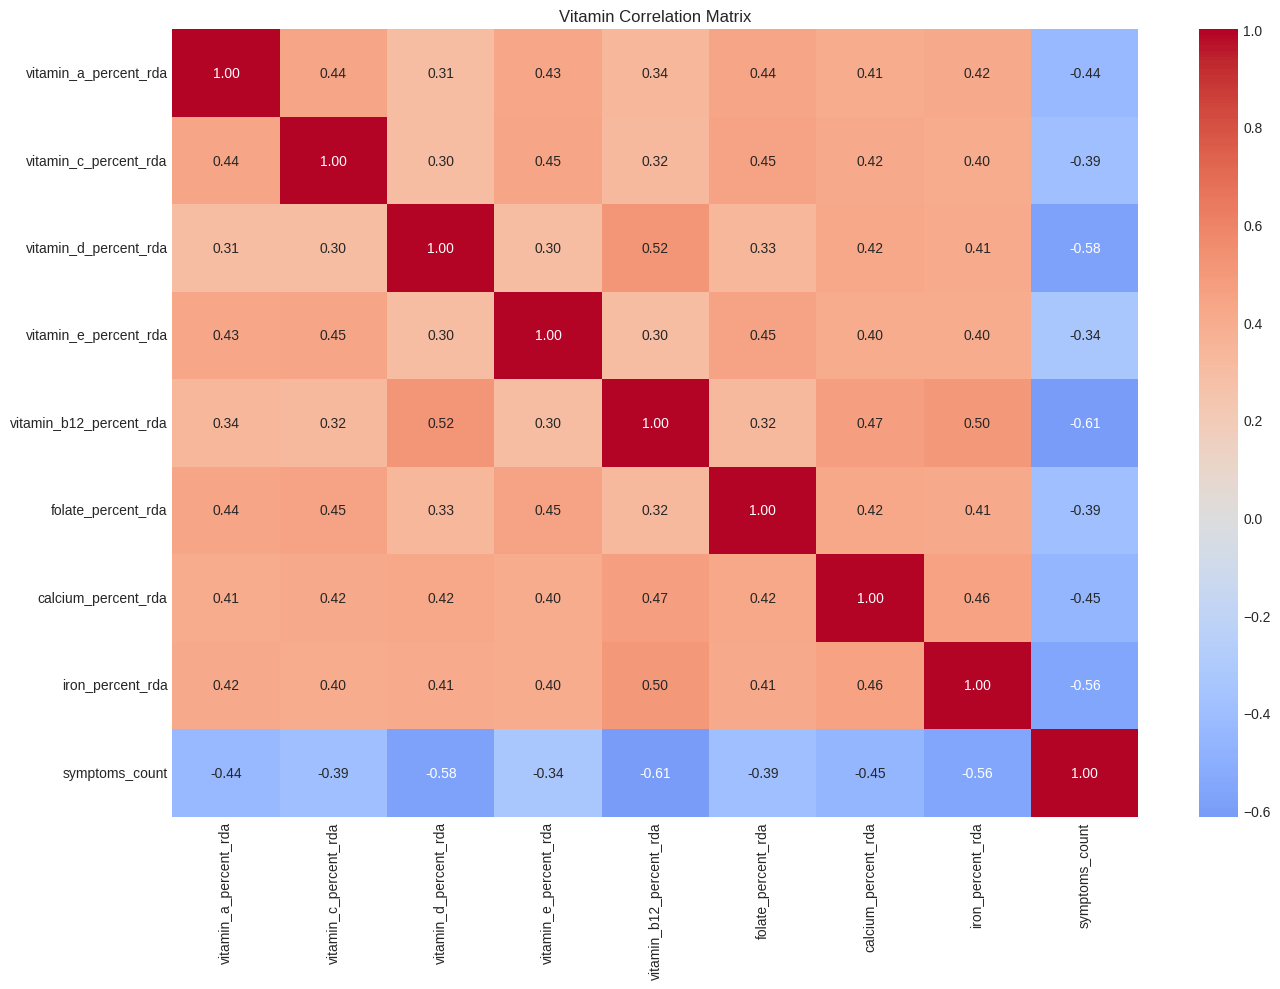

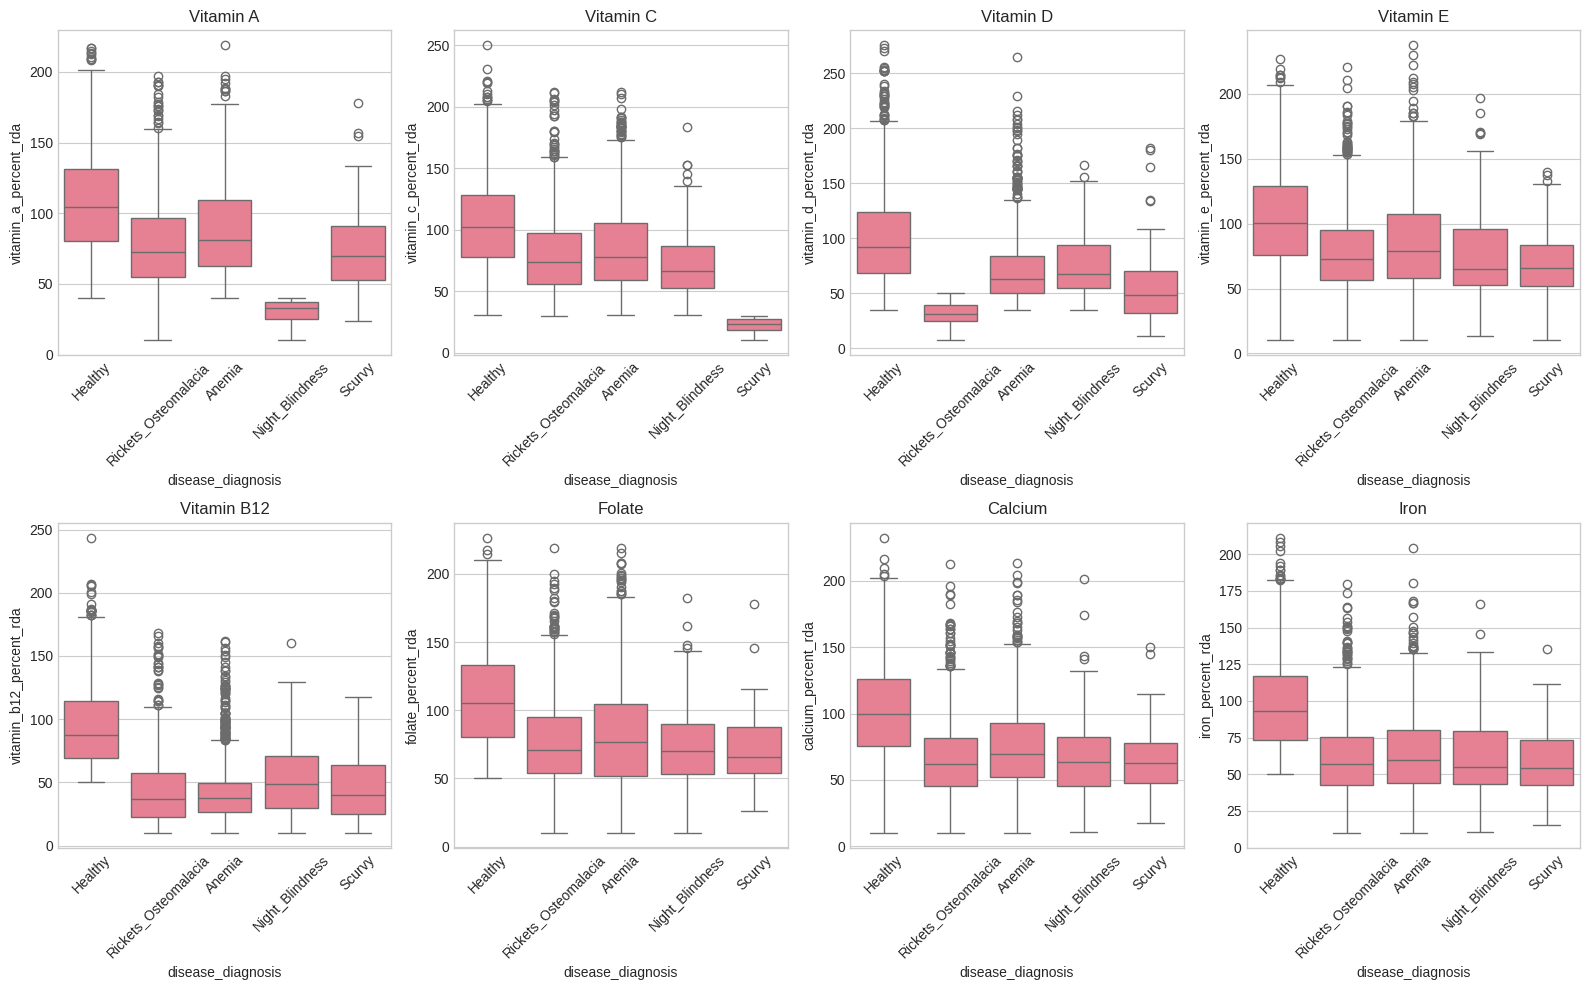

In [5]:
# 3.1 Basic Statistics
print("="*50)
print("BASIC STATISTICS")
print("="*50)

numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())

# 3.2 Target Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['disease_diagnosis'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Disease Distribution')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['disease_diagnosis'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Disease Percentage')
plt.ylabel('')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.3 Correlation Heatmap
plt.figure(figsize=(14, 10))
vitamin_cols = ['vitamin_a_percent_rda', 'vitamin_c_percent_rda',
                'vitamin_d_percent_rda', 'vitamin_e_percent_rda',
                'vitamin_b12_percent_rda', 'folate_percent_rda',
                'calcium_percent_rda', 'iron_percent_rda']
corr_matrix = df[vitamin_cols + ['symptoms_count']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Vitamin Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.4 Vitamin Levels by Disease
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(vitamin_cols):
    sns.boxplot(data=df, x='disease_diagnosis', y=col, ax=axes[idx])
    axes[idx].set_title(f'{col.replace("_percent_rda", "").replace("_", " ").title()}')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('vitamin_by_disease.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Create feature matrix
df_model = df.copy()

# Encode categorical variables
categorical_cols = ['gender', 'smoking_status', 'alcohol_consumption',
                   'exercise_level', 'diet_type', 'sun_exposure',
                   'income_level', 'latitude_region']

# One-hot encoding for initial categorical columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Create additional features
df_encoded['bmi_category'] = pd.cut(df['bmi'],
                                   bins=[0, 18.5, 25, 30, 100],
                                   labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df_encoded['age_group'] = pd.cut(df['age'],
                                bins=[0, 30, 50, 65, 100],
                                labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Encode target
le = LabelEncoder()
y = le.fit_transform(df_encoded['disease_diagnosis'])
class_names = le.classes_

# Select features for modeling (exclude non-predictive columns)
# 'bmi_category' and 'age_group' should remain in X to be one-hot encoded later.
exclude_cols_for_initial_X = ['disease_diagnosis', 'symptoms_list']
X = df_encoded.drop(columns=exclude_cols_for_initial_X)

# Handle any remaining categorical columns ('bmi_category', 'age_group')
# These columns are now present in X and can be one-hot encoded.
X = pd.get_dummies(X, columns=['bmi_category', 'age_group'], drop_first=True)

print(f"Feature matrix shape: {X.shape}")
print(f"Target classes: {class_names}")

Feature matrix shape: (4000, 46)
Target classes: ['Anemia' 'Healthy' 'Night_Blindness' 'Rickets_Osteomalacia' 'Scurvy']


In [15]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set: {np.bincount(y_train)}")
print(f"Balanced training set: {np.bincount(y_train_balanced)}")

Original training set: [ 996 1207   98  823   76]
Balanced training set: [1207 1207 1207 1207 1207]



RANDOM FOREST CLASSIFIER
Accuracy: 0.9850

Classification Report:
                      precision    recall  f1-score   support

              Anemia       0.98      0.99      0.98       249
             Healthy       1.00      0.98      0.99       302
     Night_Blindness       1.00      0.96      0.98        24
Rickets_Osteomalacia       0.98      0.99      0.98       206
              Scurvy       0.95      1.00      0.97        19

            accuracy                           0.98       800
           macro avg       0.98      0.98      0.98       800
        weighted avg       0.99      0.98      0.99       800



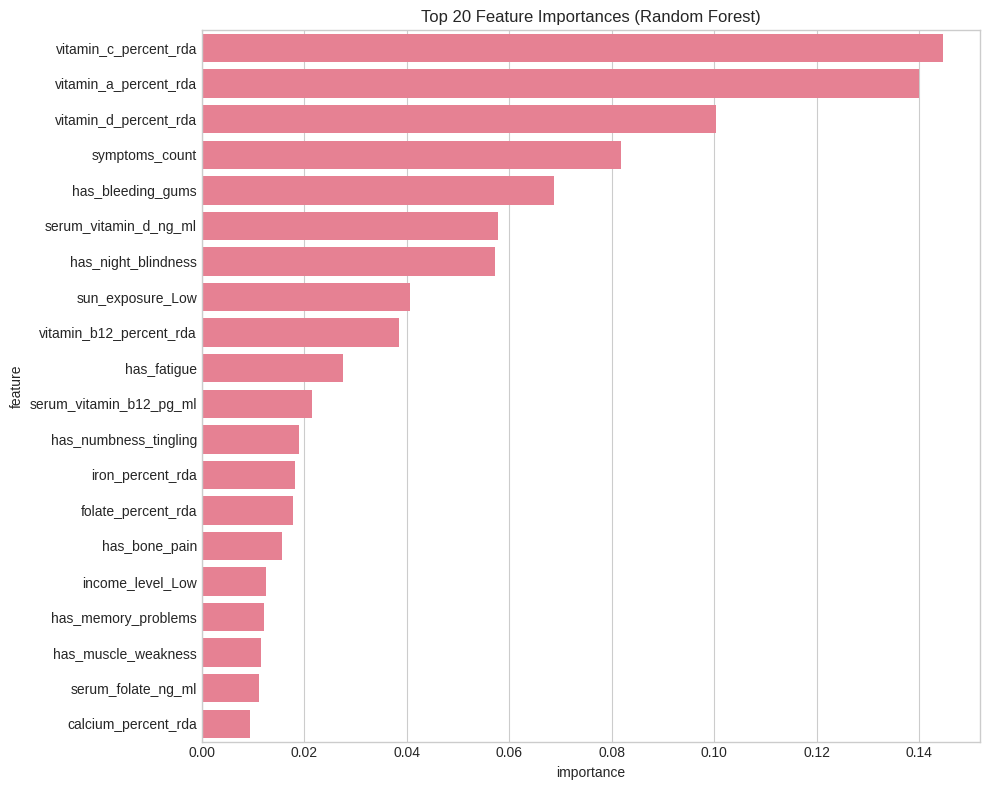


GRADIENT BOOSTING CLASSIFIER
Accuracy: 0.9988

Classification Report:
                      precision    recall  f1-score   support

              Anemia       1.00      1.00      1.00       249
             Healthy       1.00      1.00      1.00       302
     Night_Blindness       1.00      1.00      1.00        24
Rickets_Osteomalacia       1.00      1.00      1.00       206
              Scurvy       0.95      1.00      0.97        19

            accuracy                           1.00       800
           macro avg       0.99      1.00      0.99       800
        weighted avg       1.00      1.00      1.00       800



In [16]:
# 5.1 Random Forest
print("\n" + "="*50)
print("RANDOM FOREST CLASSIFIER")
print("="*50)

rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                           min_samples_split=5, random_state=42,
                           class_weight='balanced')
rf.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.2 Gradient Boosting
print("\n" + "="*50)
print("GRADIENT BOOSTING CLASSIFIER")
print("="*50)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                               max_depth=5, random_state=42)
gb.fit(X_train_balanced, y_train_balanced)
y_pred_gb = gb.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=class_names))


In [12]:
# Initialize transactions list
transactions = []

# Iterate through each row of the DataFrame to create transactions
for index, row in df.iterrows():
    transaction = []

    # Add disease diagnosis to transaction
    transaction.append(row['disease_diagnosis'])

    # Add low vitamin levels to transaction (e.g., if RDA is below 50%)
    if row['vitamin_a_percent_rda'] < 50:
        transaction.append('low_vitamin_a')
    if row['vitamin_c_percent_rda'] < 50:
        transaction.append('low_vitamin_c')
    if row['vitamin_d_percent_rda'] < 50:
        transaction.append('low_vitamin_d')
    if row['vitamin_e_percent_rda'] < 50:
        transaction.append('low_vitamin_e')
    if row['vitamin_b12_percent_rda'] < 50:
        transaction.append('low_vitamin_b12')
    if row['folate_percent_rda'] < 50:
        transaction.append('low_folate')
    if row['calcium_percent_rda'] < 50:
        transaction.append('low_calcium')
    if row['iron_percent_rda'] < 50:
        transaction.append('low_iron')

    # Add symptoms to transaction if present
    symptom_cols = ['has_night_blindness', 'has_fatigue', 'has_bleeding_gums',
                    'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling',
                    'has_memory_problems', 'has_pale_skin']
    for sym_col in symptom_cols:
        if row[sym_col] == 1:
            # Add symptom name, removing 'has_' prefix
            transaction.append(sym_col.replace('has_', ''))

    transactions.append(transaction)

# Encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets
frequent_itemsets = apriori(df_trans, min_support=0.05, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"\nFound {len(frequent_itemsets)} frequent itemsets")
print("\nTop 10 Frequent Itemsets:")
print(frequent_itemsets.head(10))

# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules = rules.sort_values('lift', ascending=False)

print(f"\nFound {len(rules)} association rules")
print("\nTop 10 Association Rules (by lift):")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


Found 502 frequent itemsets

Top 10 Frequent Itemsets:
    support                              itemsets
9   0.44000                     (low_vitamin_b12)
1   0.37725                             (Healthy)
11  0.36650                       (low_vitamin_d)
91  0.35125  (numbness_tingling, low_vitamin_b12)
16  0.35125                   (numbness_tingling)
0   0.31125                              (Anemia)
88  0.30300    (memory_problems, low_vitamin_b12)
13  0.30300                     (memory_problems)
3   0.30075                           (bone_pain)
4   0.26925                             (fatigue)

Found 1686 association rules

Top 10 Association Rules (by lift):
                                            antecedents  \
993                    (low_vitamin_a, low_vitamin_b12)   
1454                   (low_vitamin_d, night_blindness)   
994                  (night_blindness, low_vitamin_b12)   
220                                   (night_blindness)   
219                             

BASIC STATISTICS
               age          bmi  vitamin_a_percent_rda  vitamin_c_percent_rda  \
count  4000.000000  4000.000000            4000.000000            4000.000000   
mean     50.766250    26.105325              90.770850              89.199075   
std      19.306237     4.922746              37.083534              37.505809   
min      18.000000    15.000000              10.000000              10.000000   
25%      34.000000    22.800000              62.600000              60.975000   
50%      51.000000    26.200000              85.500000              83.500000   
75%      67.000000    29.400000             115.300000             113.000000   
max      84.000000    45.000000             219.000000             250.000000   

       vitamin_d_percent_rda  vitamin_e_percent_rda  vitamin_b12_percent_rda  \
count            4000.000000            4000.000000              4000.000000   
mean               72.216388              89.946125                62.743225   
std          

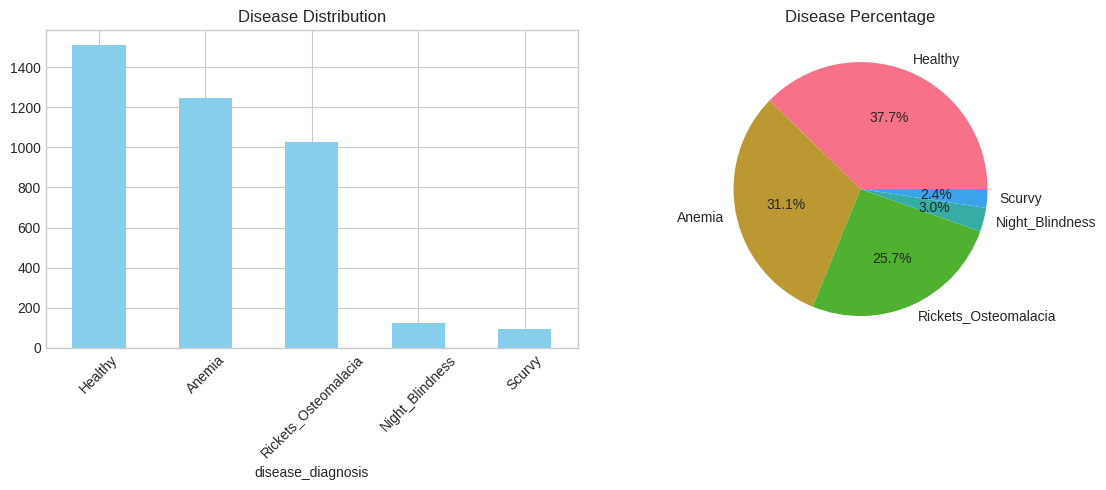

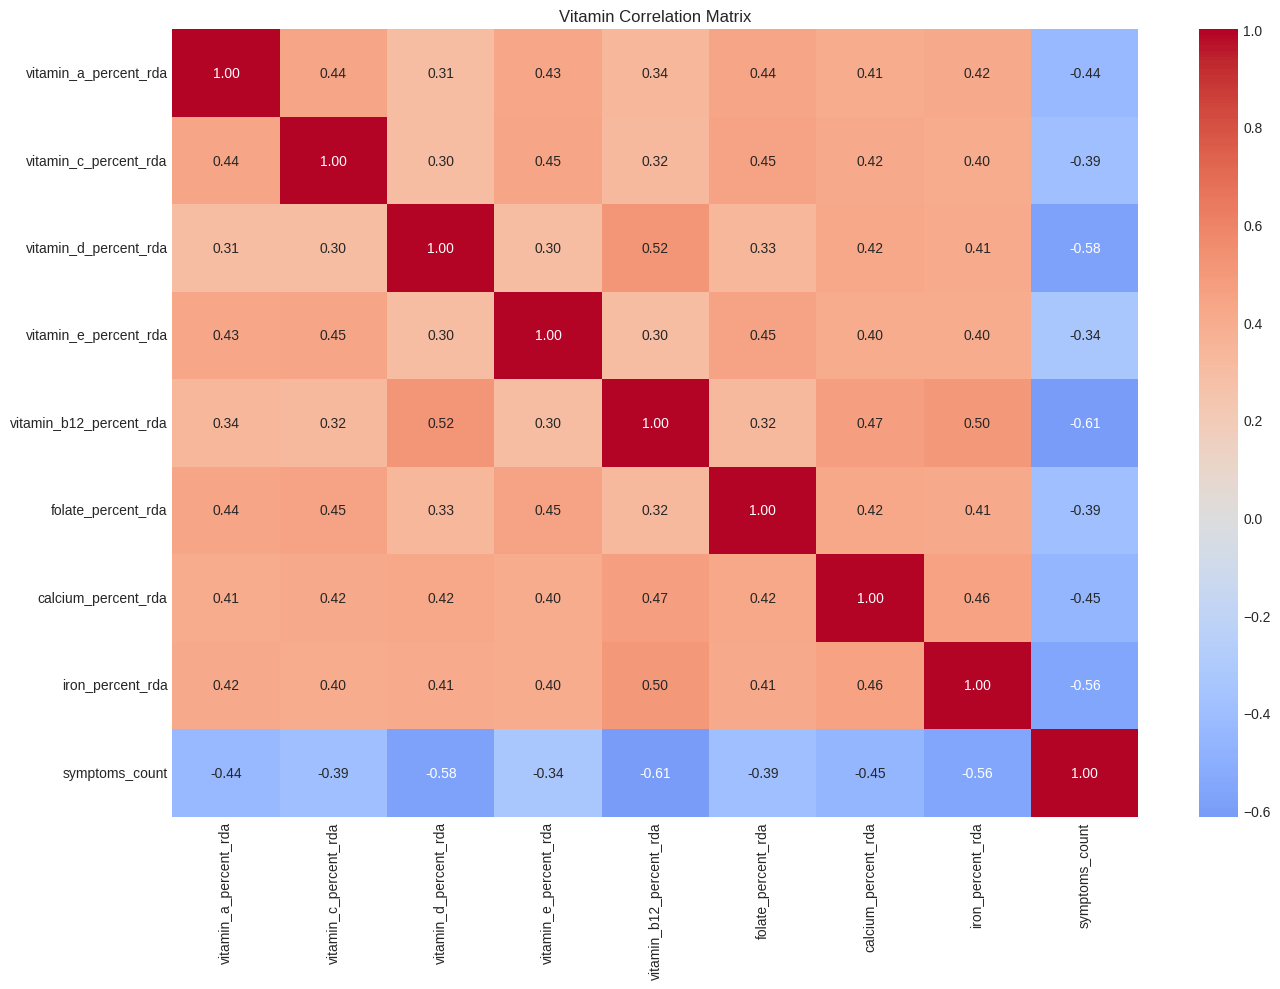

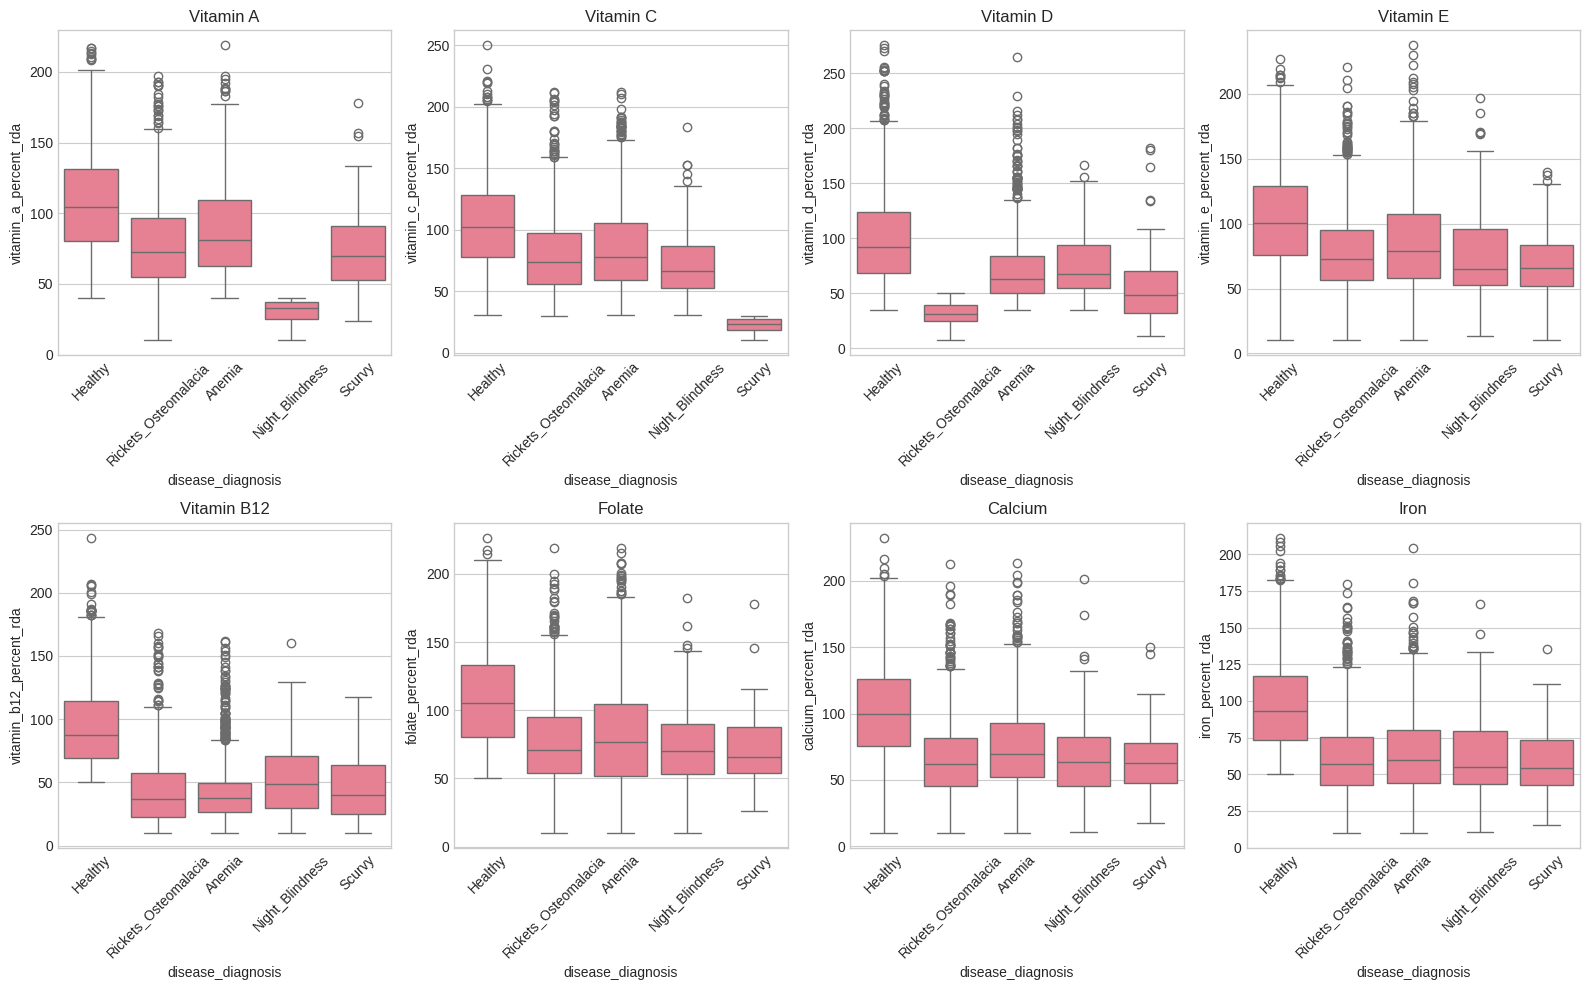

In [25]:
# ╔══════════════════════════════════════════════════════════╗
# ║           STEP 3: EXPLORATORY DATA ANALYSIS              ║
# ╚══════════════════════════════════════════════════════════╝

# 3.1 Basic Statistics
print("="*50)
print("BASIC STATISTICS")
print("="*50)

numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())

# 3.2 Target Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['disease_diagnosis'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Disease Distribution')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['disease_diagnosis'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Disease Percentage')
plt.ylabel('')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.3 Correlation Heatmap
plt.figure(figsize=(14, 10))
vitamin_cols = ['vitamin_a_percent_rda', 'vitamin_c_percent_rda',
                'vitamin_d_percent_rda', 'vitamin_e_percent_rda',
                'vitamin_b12_percent_rda', 'folate_percent_rda',
                'calcium_percent_rda', 'iron_percent_rda']
corr_matrix = df[vitamin_cols + ['symptoms_count']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Vitamin Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.4 Vitamin Levels by Disease - FIXED VERSION
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(vitamin_cols):
    sns.boxplot(data=df, x='disease_diagnosis', y=col, ax=axes[idx])
    # FIXED: Create title separately to avoid quote conflicts
    clean_name = col.replace('_percent_rda', '').replace('_', ' ').title()
    axes[idx].set_title(clean_name)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('vitamin_by_disease.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# ╔══════════════════════════════════════════════════════════╗
# ║         STEP 4: FEATURE ENGINEERING                      ║
# ╚══════════════════════════════════════════════════════════╝

# Create feature matrix
df_model = df.copy()

# Encode categorical variables
categorical_cols = ['gender', 'smoking_status', 'alcohol_consumption',
                   'exercise_level', 'diet_type', 'sun_exposure',
                   'income_level', 'latitude_region']

# One-hot encoding
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Create additional features
df_encoded['bmi_category'] = pd.cut(df['bmi'],
                                   bins=[0, 18.5, 25, 30, 100],
                                   labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df_encoded['age_group'] = pd.cut(df['age'],
                                bins=[0, 30, 50, 65, 100],
                                labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Encode target
le = LabelEncoder()
y = le.fit_transform(df_encoded['disease_diagnosis'])
class_names = le.classes_

# Select features for modeling (exclude non-predictive columns)
# 'bmi_category' and 'age_group' should remain in X to be one-hot encoded later.
exclude_cols_for_initial_X_creation = ['disease_diagnosis', 'symptoms_list']
X = df_encoded.drop(columns=exclude_cols_for_initial_X_creation)

# Handle any remaining categorical (the newly created 'bmi_category', 'age_group')
# These columns are now present in X and can be one-hot encoded.
X = pd.get_dummies(X, columns=['bmi_category', 'age_group'], drop_first=True)

print(f"Feature matrix shape: {X.shape}")
print(f"Target classes: {class_names}")

Feature matrix shape: (4000, 46)
Target classes: ['Anemia' 'Healthy' 'Night_Blindness' 'Rickets_Osteomalacia' 'Scurvy']


In [31]:
# 5.3 Model Comparison
models = {
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_balanced, y_train_balanced)
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test_scaled)

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'CV Score': np.mean(cross_val_score(model, X_train_balanced,
                                           y_train_balanced, cv=5))
    }

results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)

# ╔══════════════════════════════════════════════════════════╗
# ║         STEP 6: ASSOCIATION RULE MINING                  ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("ASSOCIATION RULE MINING")
print("="*50)


Model Comparison:
                     Accuracy  CV Score
Random Forest         0.98500  0.992046
Gradient Boosting     0.99875  0.997846
Logistic Regression   0.91875  0.947639

ASSOCIATION RULE MINING


In [32]:
# ╔══════════════════════════════════════════════════════════╗
# ║         STEP 6: ASSOCIATION RULE MINING                  ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("ASSOCIATION RULE MINING")
print("="*50)

# Prepare data for association rules
# Create binary matrix for symptoms and diseases
symptom_cols = ['has_night_blindness', 'has_fatigue', 'has_bleeding_gums',
               'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling',
               'has_memory_problems', 'has_pale_skin']

# Create transaction data
transactions = []
for _, row in df.iterrows():
    transaction = []
    # Add symptoms
    for col in symptom_cols:
        if row[col] == 1:
            transaction.append(col.replace('has_', ''))
    # Add disease
    transaction.append(row['disease_diagnosis'])
    # Add diet type
    transaction.append(row['diet_type'])
    # Add vitamin deficiency indicators (below 50% RDA)
    if row['vitamin_a_percent_rda'] < 50:
        transaction.append('low_vitamin_a')
    if row['vitamin_d_percent_rda'] < 50:
        transaction.append('low_vitamin_d')
    if row['vitamin_b12_percent_rda'] < 50:
        transaction.append('low_vitamin_b12')
    if row['vitamin_c_percent_rda'] < 50:
        transaction.append('low_vitamin_c')

    transactions.append(transaction)

# Encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets
frequent_itemsets = apriori(df_trans, min_support=0.05, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"\nFound {len(frequent_itemsets)} frequent itemsets")
print("\nTop 10 Frequent Itemsets:")
print(frequent_itemsets.head(10))

# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules = rules.sort_values('lift', ascending=False)

print(f"\nFound {len(rules)} association rules")
print("\nTop 10 Association Rules (by lift):")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


ASSOCIATION RULE MINING

Found 428 frequent itemsets

Top 10 Frequent Itemsets:
    support                              itemsets
10  0.44000                     (low_vitamin_b12)
1   0.37725                             (Healthy)
12  0.36650                       (low_vitamin_d)
16  0.35125                   (numbness_tingling)
87  0.35125  (numbness_tingling, low_vitamin_b12)
0   0.31125                              (Anemia)
84  0.30300    (memory_problems, low_vitamin_b12)
13  0.30300                     (memory_problems)
7   0.30075                           (bone_pain)
8   0.26925                             (fatigue)

Found 1447 association rules

Top 10 Association Rules (by lift):
                             antecedents                   consequents  \
983     (low_vitamin_a, low_vitamin_b12)             (night_blindness)   
984   (night_blindness, low_vitamin_b12)               (low_vitamin_a)   
1318    (low_vitamin_d, night_blindness)               (low_vitamin_a)   
243   


CLUSTERING ANALYSIS


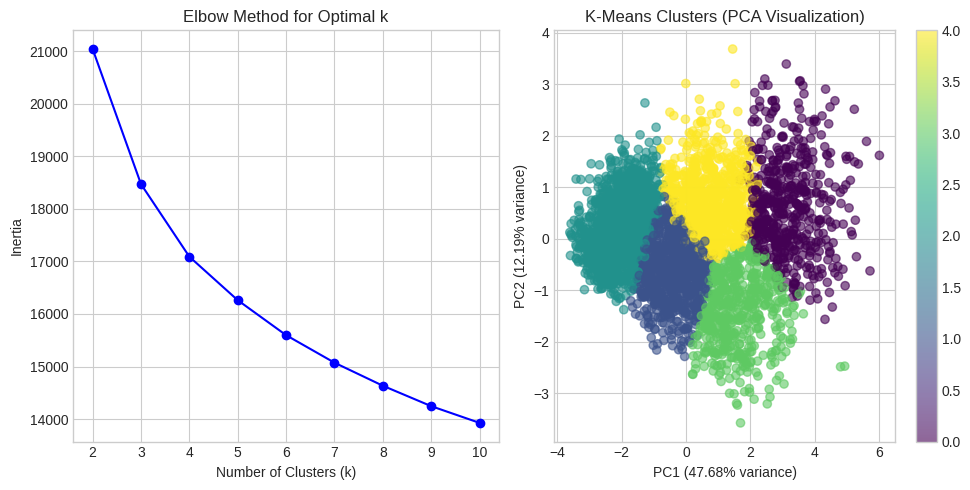


Cluster Profiles:
         vitamin_a_percent_rda  vitamin_c_percent_rda  vitamin_d_percent_rda  \
cluster                                                                        
0                   123.704340             123.578481             131.447034   
1                    94.004718              91.697117              52.590839   
2                    61.097527              59.704382              48.333279   
3                   128.481192             128.344693              65.897840   
4                    92.215710              88.920355              98.729235   

         vitamin_e_percent_rda  vitamin_b12_percent_rda  folate_percent_rda  \
cluster                                                                       
0                   123.114467               116.625316          124.237613   
1                    92.554915                42.700262           92.034469   
2                    60.552509                41.018092           60.213922   
3                   130.1

In [33]:
# ╔══════════════════════════════════════════════════════════╗
# ║         STEP 7: CLUSTERING ANALYSIS                      ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "="*50)
print("CLUSTERING ANALYSIS")
print("="*50)

# Prepare data for clustering (vitamin levels only)
vitamin_data = df[vitamin_cols].copy()
vitamin_scaled = StandardScaler().fit_transform(vitamin_data)

# K-Means Clustering
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(vitamin_scaled)
    inertias.append(kmeans.inertia_)

# Elbow plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

# Apply K-Means with optimal k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(vitamin_scaled)
df['cluster'] = clusters

# Visualize clusters with PCA
pca = PCA(n_components=2)
vitamin_pca = pca.fit_transform(vitamin_scaled)

plt.subplot(1, 2, 2)
scatter = plt.scatter(vitamin_pca[:, 0], vitamin_pca[:, 1],
                     c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clusters (PCA Visualization)')
plt.tight_layout()
plt.savefig('clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster profiles
print("\nCluster Profiles:")
cluster_summary = df.groupby('cluster')[vitamin_cols + ['symptoms_count']].mean()
print(cluster_summary)


Generating SHAP summary plot...


<Figure size 1200x800 with 0 Axes>

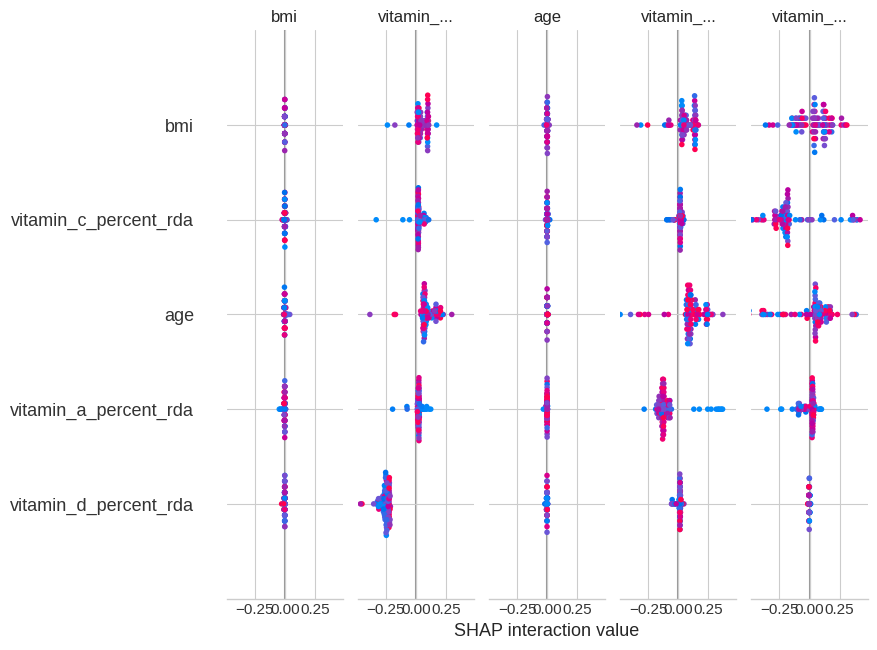


Generating UMAP visualization...


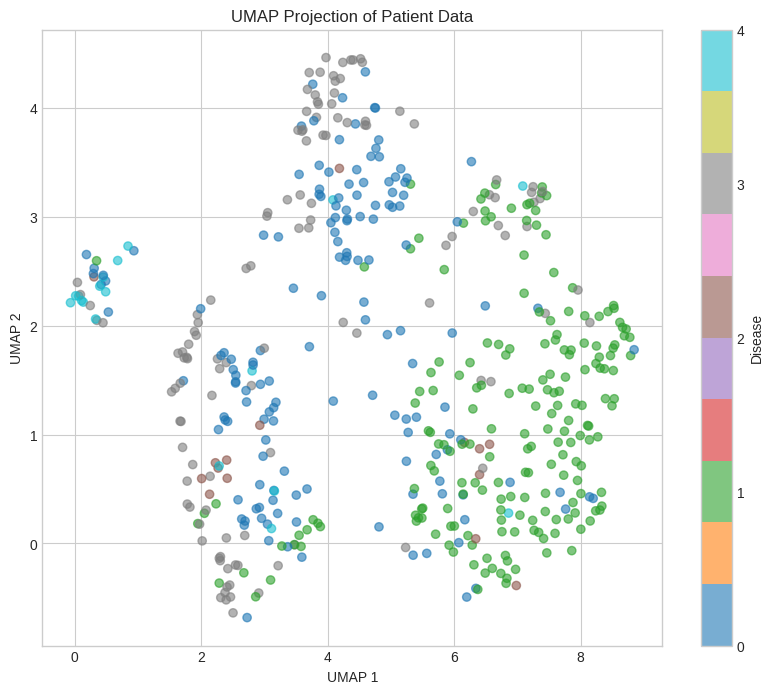

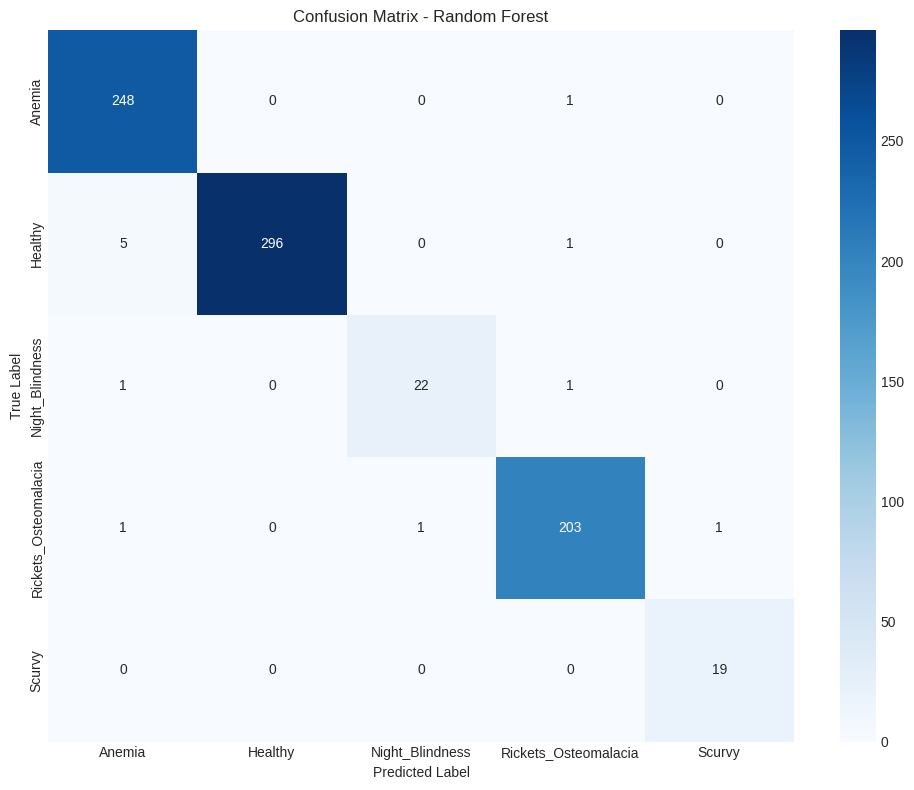

In [34]:
# ╔══════════════════════════════════════════════════════════╗
# ║         STEP 8: ADVANCED VISUALIZATIONS                  ║
# ╚══════════════════════════════════════════════════════════╝

# 8.1 SHAP Values for Model Interpretability
print("\nGenerating SHAP summary plot...")
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled[:100])  # Sample for speed

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test[:100], feature_names=X.columns, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# 8.2 UMAP Visualization
print("\nGenerating UMAP visualization...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_train_scaled[:500])  # Sample for speed

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1],
                     c=y_train[:500], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, ticks=range(len(class_names)), label='Disease')
plt.title('UMAP Projection of Patient Data')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.savefig('umap_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# 8.3 Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# ╔══════════════════════════════════════════════════════════╗
# ║         STEP 9: SAVE RESULTS & MODELS                  ║
# ╚══════════════════════════════════════════════════════════╝

# Save processed data
df.to_csv('processed_vitamin_data.csv', index=False)

# Save model
import joblib
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("\n" + "="*50)
print("DATA MINING COMPLETE!")
print("="*50)
print("\nFiles saved:")
print("- processed_vitamin_data.csv")
print("- random_forest_model.pkl")
print("- scaler.pkl")
print("- label_encoder.pkl")
print("\nVisualizations saved:")
print("- target_distribution.png")
print("- correlation_heatmap.png")
print("- vitamin_by_disease.png")
print("- feature_importance.png")
print("- clustering_analysis.png")
print("- shap_summary.png")
print("- umap_visualization.png")


DATA MINING COMPLETE!

Files saved:
- processed_vitamin_data.csv
- random_forest_model.pkl
- scaler.pkl
- label_encoder.pkl

Visualizations saved:
- target_distribution.png
- correlation_heatmap.png
- vitamin_by_disease.png
- feature_importance.png
- clustering_analysis.png
- shap_summary.png
- umap_visualization.png
